# NSBH + BNS Test Notebook (Fixed $f_j^{\mathrm{BNS}}=1.0$)

This notebook does one focused test:

1. Build the combined BNS + NSBH population
2. Plot population counts and redshift histograms
3. Run one Monte Carlo MCMC with fixed $f_j^{\mathrm{BNS}}=0.3$
4. Show the joint posterior of $(\theta_c^{\mathrm{BNS}}, \theta_c^{\mathrm{NSBH}})$

The priors for both $\theta_c^{\mathrm{BNS}}$ and $\theta_c^{\mathrm{NSBH}}$ are matched to the same interval: $1$ to $50$ deg.

In [37]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import emcee

import sys
sys.path.insert(0, '..')

plt.style.use('../configurations/style.mplstyle')
datafiles = Path('../datafiles')

print('Setup complete.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete.


In [38]:
from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)
from src.top_hat.geometric_eff import geometric_efficiency_fixed
from src.nsbh.montecarlo import GBM_EFF, FJ_NSBH_FIXED, N_MC_EVENTS
import src.init

FJ_BNS_FIXED = 1

demo_params = {
    'alpha': -0.6,
    'beta_s': -2.5,
    'n': 2.0,
    'theta_c': 3.4,
    'theta_v_max': 10.0,
    'z_model': 'fiducial_delayed_A0.5',
}

bns_params, nsbh_data, data_dict = initialize_combined_simulation(
    datafiles=datafiles,
    params=demo_params,
    size_test=2_000,
    nsbh_population='fiducial_delayed_cut',
    nsbh_alpha='A0.5',
)

k_interpolator = create_k_interpolator()
bns_distances = compute_luminosity_distance(bns_params.z_arr)
nsbh_distances = nsbh_data.distances

print(f'Fixed fj_bns = {FJ_BNS_FIXED}')
print(f'Fixed fj_nsbh (catalog) = {FJ_NSBH_FIXED}')
print(f'Population size BNS  : {len(bns_params.z_arr)}')
print(f'Population size NSBH : {len(nsbh_data.z_arr)}')
print(f'Observed yearly GRB rate: {bns_params.yearly_rate:.2f}')

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
Fixed fj_bns = 1
Fixed fj_nsbh (catalog) = 1
Population size BNS  : 60187
Population size NSBH : 18332
Observed yearly GRB rate: 18.58


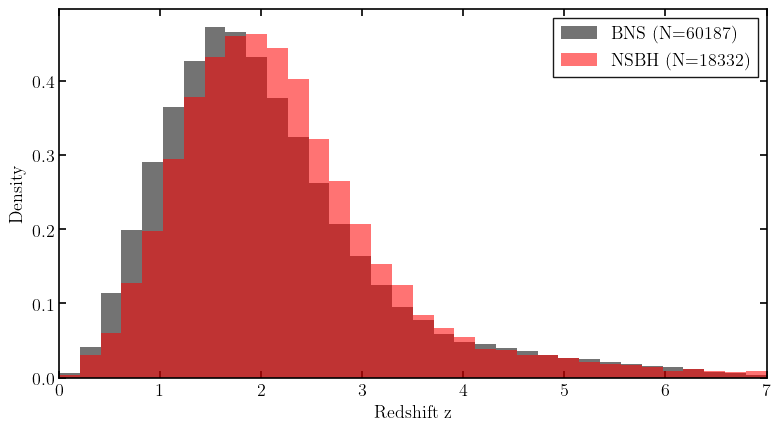

In [ ]:
# Population diagnostics: class counts and redshift distributions
n_bns       = len(bns_params.z_arr)
n_nsbh      = len(nsbh_data.z_arr)

fig, axes   = plt.subplots(figsize=(8, 4.5))
bins        = np.linspace(0, 7, 35)
axes.hist(bns_params.z_arr, bins=bins, alpha=0.55, density=True, label=f'BNS (N={n_bns})', color='k')
axes.hist(nsbh_data.z_arr, bins=bins, alpha=0.55, density=True, label=f'NSBH (N={n_nsbh})', color='r')
axes.set_xlabel('Redshift z')
axes.set_ylabel('Density')
axes.legend()
axes.set_xlim(0, 7)
plt.tight_layout()
plt.show()

## Likelihood and Priors

Priors are identical for both core angles:

- $1 < \theta_c^{\mathrm{BNS}} < 50$ deg
- $1 < \theta_c^{\mathrm{NSBH}} < 50$ deg

In [40]:
def log_likelihood_combined_fixed_fj03(
    thetas,
    bns_params,
    nsbh_data,
    bns_distances,
    nsbh_distances,
    k_interpolator,
    n_events=N_MC_EVENTS,
):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh = thetas
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    geom_eff_bns = geometric_efficiency_fixed(theta_c_bns)
    geom_eff_nsbh = geometric_efficiency_fixed(theta_c_nsbh)

    epsilon_bns = geom_eff_bns * FJ_BNS_FIXED
    epsilon_nsbh = geom_eff_nsbh * FJ_NSBH_FIXED

    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF
    intrinsic_nsbh = epsilon_nsbh * len(nsbh_data.z_arr) * GBM_EFF

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results['p_flux'], bns_results['E_p_obs']
    )

    nsbh_results = simplified_montecarlo(
        grb_thetas, n_events, nsbh_data, nsbh_distances, k_interpolator, rng=bns_params.rng
    )
    nsbh_trig, nsbh_analysis = apply_detection_cuts(
        nsbh_results['p_flux'], nsbh_results['E_p_obs']
    )

    pflux_det = np.concatenate([
        bns_results['p_flux'][bns_analysis],
        nsbh_results['p_flux'][nsbh_analysis],
    ])
    epeak_det = np.concatenate([
        bns_results['E_p_obs'][bns_analysis],
        nsbh_results['E_p_obs'][nsbh_analysis],
    ])

    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf

    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    phys_eff_bns = np.sum(bns_trig) / n_events
    phys_eff_nsbh = np.sum(nsbh_trig) / n_events

    predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns
    predicted_nsbh = intrinsic_nsbh * bns_params.triggered_years * phys_eff_nsbh
    predicted_total = predicted_bns + predicted_nsbh

    observed_total = bns_params.yearly_rate * bns_params.triggered_years
    if predicted_total <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf

    logL_poisson = poiss_log(k=observed_total, mu=predicted_total)
    return logL_pflux + logL_epeak + logL_poisson, logL_pflux, logL_epeak, logL_poisson


def log_prior_shared_theta_bounds(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh = thetas

    if not (1.5 < A_index < 12):
        return -np.inf
    if not (-2 < L_L0 < 7):
        return -np.inf
    if not (0.1 < L_mu_E < 7):
        return -np.inf
    if not (0 < sigma_E < 2.5):
        return -np.inf
    if not (1 < theta_c_bns < 50):
        return -np.inf
    if not (1 < theta_c_nsbh < 50):
        return -np.inf

    return 0.0


def initialize_walkers_shared_theta_bounds(n_walkers, seed=42):
    rng = np.random.default_rng(seed)
    return np.column_stack([
        rng.uniform(2, 3, n_walkers),
        rng.uniform(2, 4, n_walkers),
        rng.uniform(2, 4, n_walkers),
        rng.uniform(0.2, 1.0, n_walkers),
        rng.uniform(5, 12, n_walkers),
        rng.uniform(5, 12, n_walkers),
    ])

In [41]:
# Run one MCMC for fj_bns = 0.3
N_PARAMS    = 6
N_WALKERS   = 20
N_STEPS     = 50_000

run_name = 'NSBH_universal_fixed_fjBNS_1p0_test'
out_dir = src.init.create_run_dir(run_name, output_files_default='Output_files')
backend_path = out_dir / 'emcee.h5'

def log_probability(thetas):
    lp = log_prior_shared_theta_bounds(thetas)
    if not np.isfinite(lp):
        return -np.inf, 0.0, 0.0, 0.0

    ll = log_likelihood_combined_fixed_fj03(
        thetas=thetas,
        bns_params=bns_params,
        nsbh_data=nsbh_data,
        bns_distances=bns_distances,
        nsbh_distances=nsbh_distances,
        k_interpolator=k_interpolator,
        n_events=N_MC_EVENTS,
    )
    if not np.isfinite(ll[0]):
        return -np.inf, 0.0, 0.0, 0.0

    return lp + ll[0], ll[1], ll[2], ll[3]

initial_pos, n_steps_remaining, backend = check_and_resume_mcmc(
    filename=backend_path,
    n_steps=N_STEPS,
    initialize_walkers_func=initialize_walkers_shared_theta_bounds,
    n_walkers=N_WALKERS,
)

print(f'Running MCMC (fj_bns={FJ_BNS_FIXED}) in: {out_dir}')
sampler = run_mcmc(
    log_probability_func=log_probability,
    initial_walkers=initial_pos,
    n_iterations=n_steps_remaining,
    n_walkers=N_WALKERS,
    n_params=N_PARAMS,
    backend=backend,
    blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float)],
)
print(f'Completed: {backend.iteration} total steps saved.')

Loading existing directory  : Output_files/NSBH_universal_fixed_fjBNS_1p0_test
Continuing from iteration 30000
Running MCMC (fj_bns=1) in: Output_files/NSBH_universal_fixed_fjBNS_1p0_test


100%|██████████| 20000/20000 [32:48<00:00, 10.16it/s]

Completed: 50000 total steps saved.


In [42]:
# Run one BNS-only MCMC for fj_bns = 0.3 with the same theta prior bounds (1 to 50 deg)
N_PARAMS_BNS_ONLY   = 5
N_WALKERS_BNS_ONLY  = 20
N_STEPS_BNS_ONLY    = N_STEPS

def log_likelihood_bns_only_fixed_fj03(
    thetas,
    bns_params,
    bns_distances,
    k_interpolator,
    n_events=N_MC_EVENTS,
):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns = thetas
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    geom_eff_bns = geometric_efficiency_fixed(theta_c_bns)
    epsilon_bns = geom_eff_bns * FJ_BNS_FIXED
    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results['p_flux'], bns_results['E_p_obs']
    )

    pflux_det = bns_results['p_flux'][bns_analysis]
    epeak_det = bns_results['E_p_obs'][bns_analysis]

    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf

    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    phys_eff_bns = np.sum(bns_trig) / n_events
    predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns

    observed_total = bns_params.yearly_rate * bns_params.triggered_years
    if predicted_bns <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf

    logL_poisson = poiss_log(k=observed_total, mu=predicted_bns)
    return logL_pflux + logL_epeak + logL_poisson, logL_pflux, logL_epeak, logL_poisson

def log_prior_bns_only_shared_theta_bounds(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns = thetas

    if not (1.5 < A_index < 12):
        return -np.inf
    if not (-2 < L_L0 < 7):
        return -np.inf
    if not (0.1 < L_mu_E < 7):
        return -np.inf
    if not (0 < sigma_E < 2.5):
        return -np.inf
    if not (1 < theta_c_bns < 50):
        return -np.inf

    return 0.0

def initialize_walkers_bns_only_shared_theta_bounds(n_walkers, seed=42):
    rng = np.random.default_rng(seed)
    return np.column_stack([
        rng.uniform(2, 3, n_walkers),
        rng.uniform(2, 4, n_walkers),
        rng.uniform(2, 4, n_walkers),
        rng.uniform(0.2, 1.0, n_walkers),
        rng.uniform(5, 12, n_walkers),
    ])


run_name_bns_only = 'NSBH_universal_BNS_only_fjBNS_1p0_theta50_test'
out_dir_bns_only = src.init.create_run_dir(run_name_bns_only, output_files_default='Output_files')
backend_path_bns_only = out_dir_bns_only / 'emcee.h5'


def log_probability_bns_only(thetas):
    lp = log_prior_bns_only_shared_theta_bounds(thetas)
    if not np.isfinite(lp):
        return -np.inf, 0.0, 0.0, 0.0

    ll = log_likelihood_bns_only_fixed_fj03(
        thetas=thetas,
        bns_params=bns_params,
        bns_distances=bns_distances,
        k_interpolator=k_interpolator,
        n_events=N_MC_EVENTS,
    )
    if not np.isfinite(ll[0]):
        return -np.inf, 0.0, 0.0, 0.0

    return lp + ll[0], ll[1], ll[2], ll[3]


initial_pos_bns_only, n_steps_remaining_bns_only, backend_bns_only = check_and_resume_mcmc(
    filename=backend_path_bns_only,
    n_steps=N_STEPS_BNS_ONLY,
    initialize_walkers_func=initialize_walkers_bns_only_shared_theta_bounds,
    n_walkers=N_WALKERS_BNS_ONLY,
)

print(f'Running BNS-only MCMC (fj_bns={FJ_BNS_FIXED}) in: {out_dir_bns_only}')
sampler_bns_only = run_mcmc(
    log_probability_func=log_probability_bns_only,
    initial_walkers=initial_pos_bns_only,
    n_iterations=n_steps_remaining_bns_only,
    n_walkers=N_WALKERS_BNS_ONLY,
    n_params=N_PARAMS_BNS_ONLY,
    backend=backend_bns_only,
    blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float)],
)
print(f'Completed BNS-only run: {backend_bns_only.iteration} total steps saved.')

Loading existing directory  : Output_files/NSBH_universal_BNS_only_fjBNS_1p0_theta50_test
Continuing from iteration 30000
Running BNS-only MCMC (fj_bns=1) in: Output_files/NSBH_universal_BNS_only_fjBNS_1p0_theta50_test


100%|██████████| 20000/20000 [23:19<00:00, 14.29it/s]

Completed BNS-only run: 50000 total steps saved.


Combined samples (with NSBH): 67000
BNS-only samples             : 67000
BNS-only backend path        : Output_files/NSBH_universal_BNS_only_fjBNS_1p0_theta50_test/emcee.h5


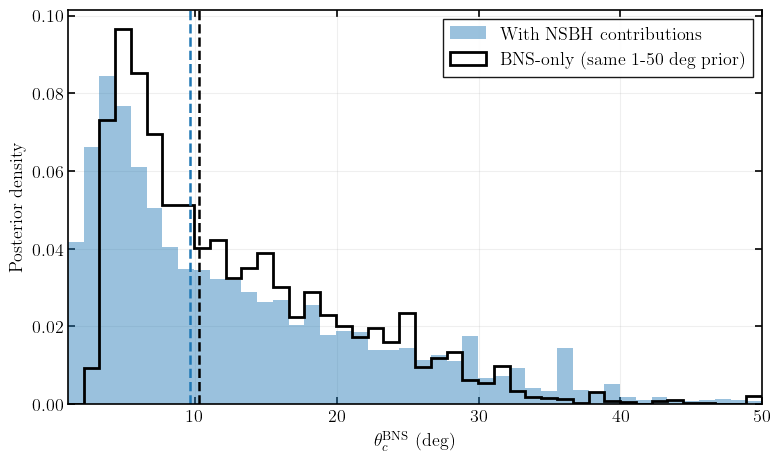

Median theta_c_BNS (with NSBH) = 9.66 deg
Median theta_c_BNS (BNS-only)  = 10.27 deg
Delta median (with - only)     = -0.61 deg


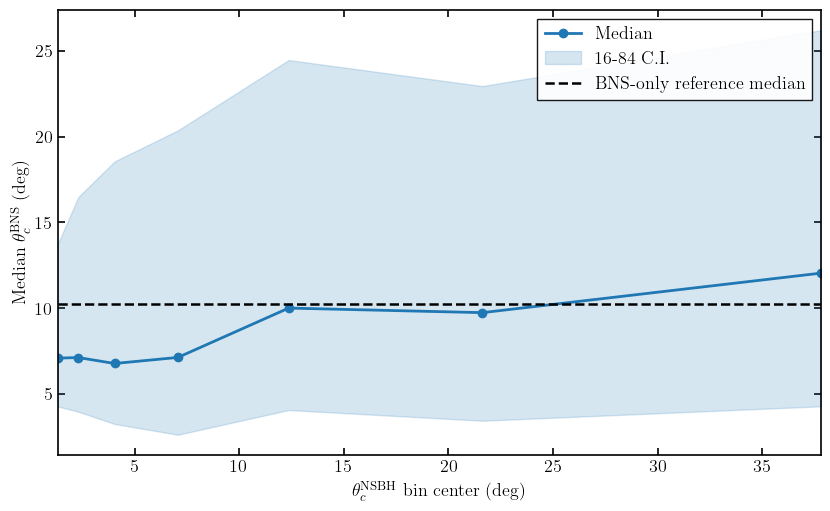

In [43]:
# Comparison cell for fj_bns = 0.3: BNS-only vs combined (with NSBH)
burn_frac = 0.33
thin = 10
fj_bns_fixed = 0.3

combined_backend_path = backend_path

backend_bns_only_path = Path('Output_files/NSBH_universal_BNS_only_fjBNS_1p0_theta50_test/emcee.h5')
backend_bns_and_nsbh_path = Path('Output_files/NSBH_universal_fixed_fjBNS_1p0_test/emcee.h5')

# Load combined samples (with NSBH contribution)
backend_combined = emcee.backends.HDFBackend(combined_backend_path)
burn_combined = int(backend_combined.iteration * burn_frac)
flat_combined = backend_combined.get_chain(discard=burn_combined, thin=thin, flat=True)

# Load BNS-only samples
backend_bns_only = emcee.backends.HDFBackend(backend_bns_only_path)
burn_bns_only = int(backend_bns_only.iteration * burn_frac)
flat_bns_only = backend_bns_only.get_chain(discard=burn_bns_only, thin=thin, flat=True)

# Parameter columns: theta_c_BNS -> 4, theta_c_NSBH -> 5
theta_bns_with_nsbh = flat_combined[:, 4]
theta_nsbh = flat_combined[:, 5]
theta_bns_only = flat_bns_only[:, 4]

print(f'Combined samples (with NSBH): {len(flat_combined)}')
print(f'BNS-only samples             : {len(flat_bns_only)}')
print(f'BNS-only backend path        : {backend_bns_only_path}')

# --- Plot 1: Posterior overlay for theta_c_BNS ---
fig, ax = plt.subplots(figsize=(8.0, 4.8))
bins = np.linspace(1, 50, 45)

ax.hist(
    theta_bns_with_nsbh,
    bins=bins,
    density=True,
    alpha=0.45,
    color='C0',
    label='With NSBH contributions',
)
ax.hist(
    theta_bns_only,
    bins=bins,
    density=True,
    histtype='step',
    linewidth=2.0,
    color='black',
    label='BNS-only (same 1-50 deg prior)',
)

med_with = np.median(theta_bns_with_nsbh)
med_only = np.median(theta_bns_only)
ax.axvline(med_with, color='C0', ls='--', lw=1.8)
ax.axvline(med_only, color='black', ls='--', lw=1.8)

ax.set_xlim(1, 50)
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg)')
ax.set_ylabel('Posterior density')
ax.grid(True, alpha=0.2)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

print(f'Median theta_c_BNS (with NSBH) = {med_with:.2f} deg')
print(f'Median theta_c_BNS (BNS-only)  = {med_only:.2f} deg')
print(f'Delta median (with - only)     = {med_with - med_only:.2f} deg')

# --- Plot 2: Median theta_c_BNS vs theta_c_NSBH bins ---
nsbh_bins = np.logspace(np.log10(1.0), np.log10(50.0), 8)
nsbh_bin_centers = np.sqrt(nsbh_bins[:-1] * nsbh_bins[1:])

binned_medians = []
binned_lows = []
binned_highs = []
for left, right in zip(nsbh_bins[:-1], nsbh_bins[1:]):
    mask = (theta_nsbh >= left) & (theta_nsbh < right)
    subset = theta_bns_with_nsbh[mask]
    if len(subset) == 0:
        binned_medians.append(np.nan)
        binned_lows.append(np.nan)
        binned_highs.append(np.nan)
    else:
        binned_medians.append(np.median(subset))
        binned_lows.append(np.percentile(subset, 16))
        binned_highs.append(np.percentile(subset, 84))

fig, ax = plt.subplots(figsize=(8.5, 5.3))
ax.plot(
    nsbh_bin_centers,
    binned_medians,
    marker='o',
    color='C0',
    lw=2,
    label='Median',
)
ax.fill_between(
    nsbh_bin_centers,
    binned_lows,
    binned_highs,
    color='C0',
    alpha=0.18,
    label='16-84 C.I.',
)
ax.axhline(
    med_only,
    color='black',
    ls='--',
    lw=1.8,
    label='BNS-only reference median',
)
ax.set_xlim(nsbh_bin_centers.min(), nsbh_bin_centers.max())
ax.set_xlabel(r'$\theta_c^{\mathrm{NSBH}}$ bin center (deg)')
ax.set_ylabel(r'Median $\theta_c^{\mathrm{BNS}}$ (deg)')
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

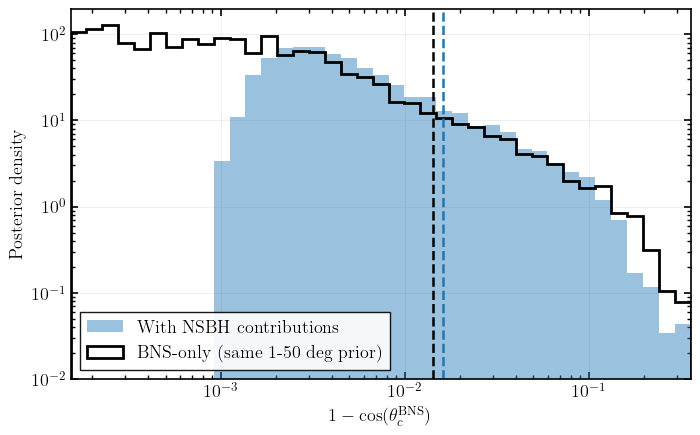

In [55]:
# Parameter columns: theta_c_BNS -> 4, theta_c_NSBH -> 5
theta_bns_with_nsbh = flat_combined[:, 4]
theta_nsbh          = flat_combined[:, 5]
theta_bns_only      = flat_bns_only[:, 4]

geo_factor_bns_only = 1 - np.cos(np.radians(theta_bns_only))
geo_factor_bns      = 1 - np.cos(np.radians(theta_bns_with_nsbh))
geo_factor_nsbh     = 1 - np.cos(np.radians(theta_nsbh))

median_bns_only     = np.median(theta_bns_only)
median_bns = np.median(theta_bns_with_nsbh)

#bins_bns = np.linspace(1, 50, 45)
#bin_geom = np.logspace(0, 1 - np.cos(np.radians(50)), 45)
# logscale
bin_geom = np.logspace(np.log10(1 - np.cos(np.radians(1))), np.log10(1 - np.cos(np.radians(50))), 40)


fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.hist(
    geo_factor_bns_only,
    bins=bin_geom,
    density=True,
    alpha=0.45,
    color='C0',
    label='With NSBH contributions',
    log=True,
)
ax.hist(
    geo_factor_bns,
    bins=bin_geom,
    density=True,
    histtype='step',
    linewidth=2.0,
    color='black',
    label='BNS-only (same 1-50 deg prior)',
    log=True,
)
ax.axvline(1 - np.cos(np.radians(median_bns_only)), color='C0', ls='--', lw=1.8)
ax.axvline(1 - np.cos(np.radians(median_bns)), color='black', ls='--', lw=1.8)
ax.set_xlabel(r'$1 - \cos(\theta_c^{\mathrm{BNS}})$')
ax.set_ylabel('Posterior density')
ax.grid(True, alpha=0.2)
ax.legend(loc="lower left")
ax.set_ylim(bottom=1e-2)
#ax.set_xlim(0, 1 - np.cos(np.radians(50)))
ax.set_xlim(1 - np.cos(np.radians(1)), 1 - np.cos(np.radians(50)))
ax.set_xscale('log')

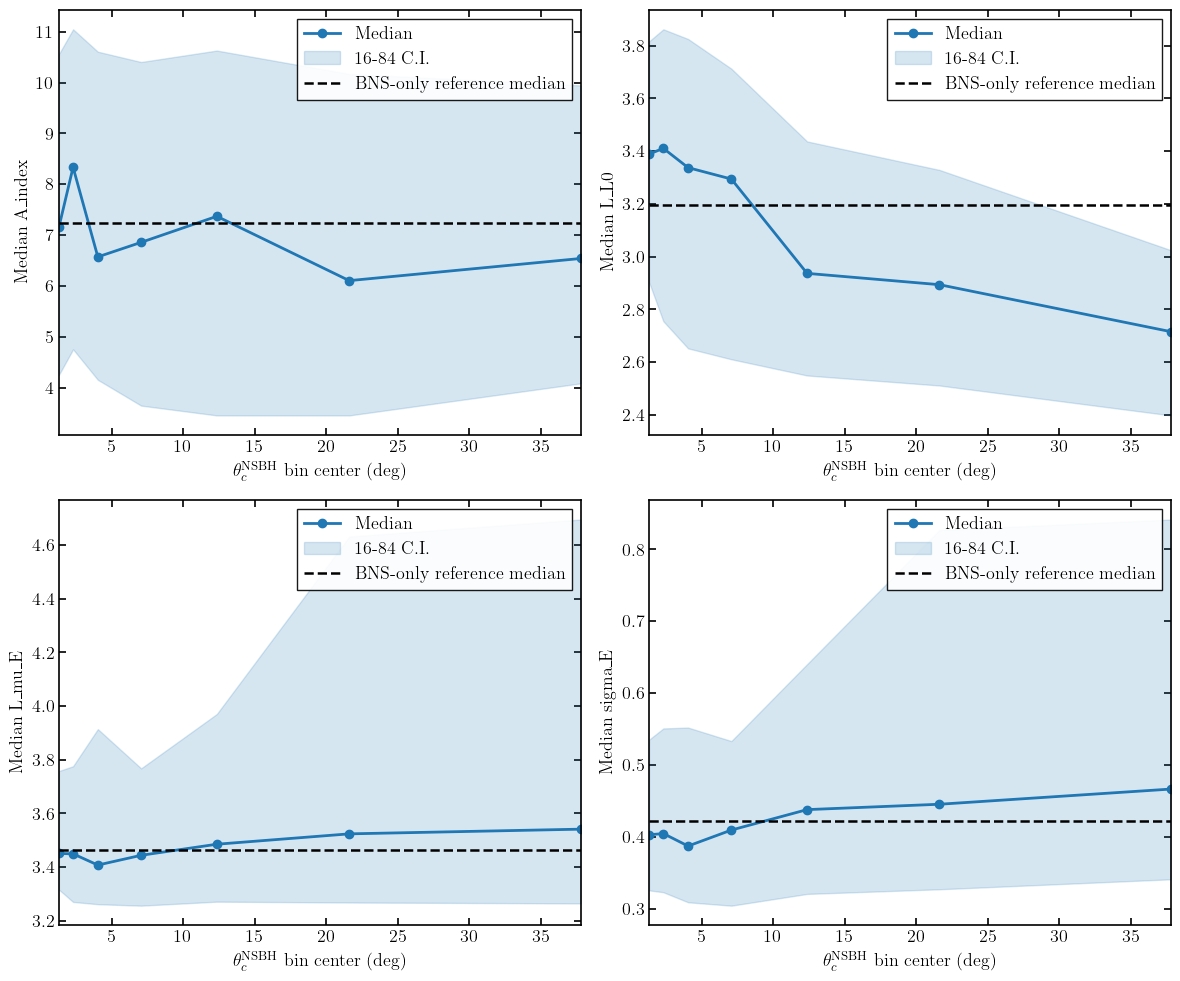

In [44]:
# plot the medians of all the other parameters as a function of theta_c_NSBB to see if there are any trends there as well. vs the BNS-only medians for reference.
# normalize the parameters to the BNS-only medians to see if there are any relative shifts as a function of theta_c_NSBB. This can help identify if the presence of NSBH contributions is systematically biasing the inferred parameters for BNS in a way that depends on the NSBH jet structure.
other_param_indices = [0, 1, 2, 3]  # A_index, L_L0, L_mu_E, sigma_E
other_param_names = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E']
bns_only_medians = []
for idx in other_param_indices:
    bns_only_medians.append(np.median(flat_bns_only[:, idx]))
fig, axes = plt.subplots(2, 2, figsize=(12.0, 10.0))
for i, (idx, name) in enumerate(zip(other_param_indices, other_param_names)):
    binned_medians = []
    binned_lows = []
    binned_highs = []
    for left, right in zip(nsbh_bins[:-1], nsbh_bins[1:]):
        mask = (theta_nsbh >= left) & (theta_nsbh < right)
        subset = flat_combined[:, idx][mask]
        if len(subset) == 0:
            binned_medians.append(np.nan)
            binned_lows.append(np.nan)
            binned_highs.append(np.nan)
        else:
            binned_medians.append(np.median(subset))
            binned_lows.append(np.percentile(subset, 16))
            binned_highs.append(np.percentile(subset, 84))

    ax = axes[i // 2, i % 2]
    ax.plot(
        nsbh_bin_centers,
        binned_medians,
        marker='o',
        color='C0',
        lw=2,
        label='Median',
    )
    ax.fill_between(
        nsbh_bin_centers,
        binned_lows,
        binned_highs,
        color='C0',
        alpha=0.18,
        label='16-84 C.I.',
    )
    ax.axhline(
        bns_only_medians[i],
        color='black',
        ls='--',
        lw=1.8,
        label='BNS-only reference median',
    )
    ax.set_xlim(nsbh_bin_centers.min(), nsbh_bin_centers.max())
    ax.set_xlabel(r'$\theta_c^{\mathrm{NSBH}}$ bin center (deg)')
    ax.set_ylabel(f'Median {name}')
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

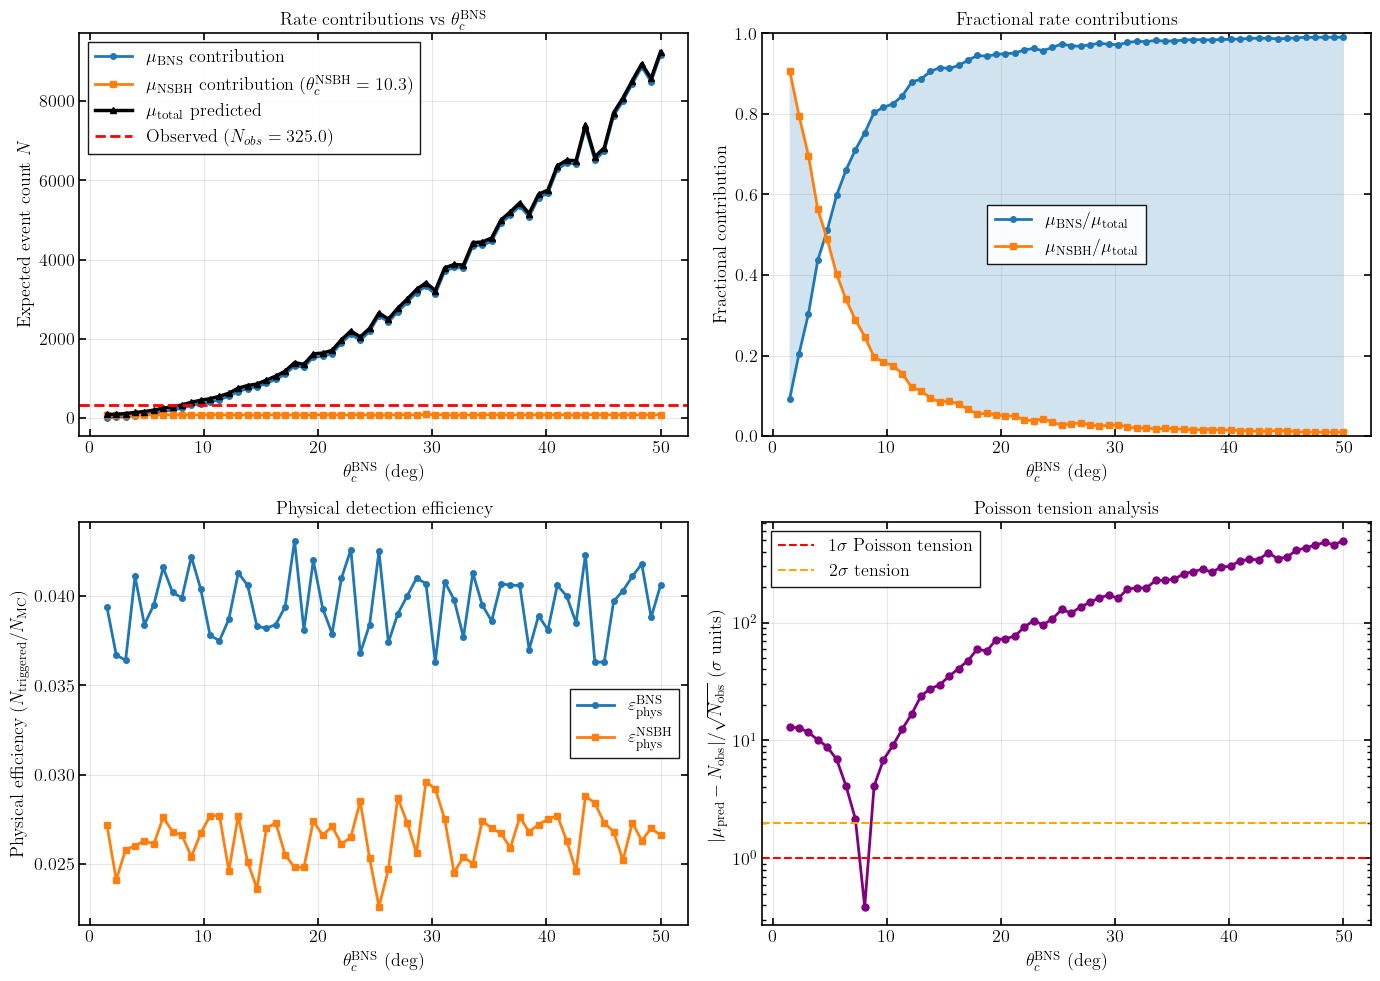


=== Rate Coupling Analysis ===
Population sizes: $N_{\mathrm{BNS}}$ = 60187, $N_{\mathrm{NSBH}}$ = 18332
Ratio $N_{\mathrm{BNS}} / N_{\mathrm{NSBH}}$ = 3.28
Observed total rate $N_{\mathrm{obs}}$: 325.00

At $\theta_c^{\mathrm{BNS}}$ = 1.5°:
  Predicted $\mu_{\mathrm{BNS}}$: 8.53, $\mu_{\mathrm{NSBH}}$: 83.85, $\mu_{\mathrm{total}}$: 92.38
  Fraction: $f_{\mathrm{BNS}}$ = 9.23%, $f_{\mathrm{NSBH}}$ = 90.77%

At $\theta_c^{\mathrm{BNS}}$ = 50.0°:
  Predicted $\mu_{\mathrm{BNS}}$: 9162.82, $\mu_{\mathrm{NSBH}}$: 82.00, $\mu_{\mathrm{total}}$: 9244.82
  Fraction: $f_{\mathrm{BNS}}$ = 99.11%, $f_{\mathrm{NSBH}}$ = 0.89%


In [61]:
# Diagnostic: Rate coupling mechanism
# Show how $\mu_{\mathrm{BNS}}$ and $\mu_{\mathrm{NSBH}}$ trade off as $\theta_c^{\mathrm{BNS}}$ varies
# while $\theta_c^{\mathrm{NSBH}}$ is held fixed at BNS-only median

observed_total = bns_params.yearly_rate * bns_params.triggered_years
theta_bns_scan = np.linspace(1.5, 50, 60)
theta_nsbh_fixed = np.median(flat_bns_only[:, 4])  # Use BNS-only median as reference

predicted_bns_list = []
predicted_nsbh_list = []
phys_eff_bns_list = []
phys_eff_nsbh_list = []

# Use median spectral parameters from BNS-only run
median_params_bns_only = np.median(flat_bns_only[:, :4], axis=0)
grb_thetas_fixed = median_params_bns_only

for theta_c_bns_val in theta_bns_scan:
    geom_eff_bns = geometric_efficiency_fixed(theta_c_bns_val)
    geom_eff_nsbh = geometric_efficiency_fixed(theta_nsbh_fixed)
    
    epsilon_bns = geom_eff_bns * FJ_BNS_FIXED
    epsilon_nsbh = geom_eff_nsbh * FJ_NSBH_FIXED
    
    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF
    intrinsic_nsbh = epsilon_nsbh * len(nsbh_data.z_arr) * GBM_EFF
    
    bns_results = simplified_montecarlo(
        grb_thetas_fixed, N_MC_EVENTS, bns_params, bns_distances, k_interpolator
    )
    bns_trig, _ = apply_detection_cuts(bns_results['p_flux'], bns_results['E_p_obs'])
    phys_eff_bns_val = np.sum(bns_trig) / N_MC_EVENTS
    
    nsbh_results = simplified_montecarlo(
        grb_thetas_fixed, N_MC_EVENTS, nsbh_data, nsbh_distances, k_interpolator, rng=bns_params.rng
    )
    nsbh_trig, _ = apply_detection_cuts(nsbh_results['p_flux'], nsbh_results['E_p_obs'])
    phys_eff_nsbh_val = np.sum(nsbh_trig) / N_MC_EVENTS
    
    predicted_bns_val = intrinsic_bns * bns_params.triggered_years * phys_eff_bns_val
    predicted_nsbh_val = intrinsic_nsbh * bns_params.triggered_years * phys_eff_nsbh_val
    
    predicted_bns_list.append(predicted_bns_val)
    predicted_nsbh_list.append(predicted_nsbh_val)
    phys_eff_bns_list.append(phys_eff_bns_val)
    phys_eff_nsbh_list.append(phys_eff_nsbh_val)

predicted_bns_arr = np.array(predicted_bns_list)
predicted_nsbh_arr = np.array(predicted_nsbh_list)
predicted_total_arr = predicted_bns_arr + predicted_nsbh_arr

# Plot the rate contributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Individual and total predictions
ax = axes[0, 0]
ax.plot(theta_bns_scan, predicted_bns_arr, 'o-', label=r'$\mu_{\mathrm{BNS}}$ contribution', color='C0', lw=2, ms=4)
ax.plot(theta_bns_scan, predicted_nsbh_arr, 's-', label=fr'$\mu_{{\mathrm{{NSBH}}}}$ contribution ($\theta_c^{{\mathrm{{NSBH}}}}={theta_nsbh_fixed:.1f}°$)', color='C1', lw=2, ms=4)
ax.plot(theta_bns_scan, predicted_total_arr, '^-', label=r'$\mu_{\mathrm{total}}$ predicted', color='black', lw=2.5, ms=5)
ax.axhline(observed_total, color='red', ls='--', lw=2, label=fr'Observed ($N_{{obs}}={observed_total:.1f}$)')
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg)')
ax.set_ylabel(r'Expected event count $N$')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_title(r'Rate contributions vs $\theta_c^{\mathrm{BNS}}$')

# Panel 2: Fractional contributions
ax = axes[0, 1]
frac_bns = predicted_bns_arr / predicted_total_arr
frac_nsbh = predicted_nsbh_arr / predicted_total_arr
ax.plot(theta_bns_scan, frac_bns, 'o-', label=r'$\mu_{\mathrm{BNS}} / \mu_{\mathrm{total}}$', color='C0', lw=2, ms=4)
ax.plot(theta_bns_scan, frac_nsbh, 's-', label=r'$\mu_{\mathrm{NSBH}} / \mu_{\mathrm{total}}$', color='C1', lw=2, ms=4)
ax.fill_between(theta_bns_scan, frac_bns, frac_nsbh, alpha=0.2)
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg)')
ax.set_ylabel(r'Fractional contribution')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])
ax.set_title(r'Fractional rate contributions')

# Panel 3: Physical efficiencies
ax = axes[1, 0]
ax.plot(theta_bns_scan, phys_eff_bns_list, 'o-', label=r'$\varepsilon_{\mathrm{phys}}^{\mathrm{BNS}}$', color='C0', lw=2, ms=4)
ax.plot(theta_bns_scan, phys_eff_nsbh_list, 's-', label=r'$\varepsilon_{\mathrm{phys}}^{\mathrm{NSBH}}$', color='C1', lw=2, ms=4)
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg)')
ax.set_ylabel(r'Physical efficiency ($N_{\mathrm{triggered}} / N_{\mathrm{MC}}$)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_title(r'Physical detection efficiency')

# Panel 4: Show the "tension" - how far off from observed rate
ax = axes[1, 1]
tension = np.abs(predicted_total_arr - observed_total) / np.sqrt(observed_total)
ax.semilogy(theta_bns_scan, tension, 'o-', color='purple', lw=2, ms=5)
ax.axhline(1, color='red', ls='--', lw=1.5, label=r'$1\sigma$ Poisson tension')
ax.axhline(2, color='orange', ls='--', lw=1.5, label=r'$2\sigma$ tension')
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg)')
ax.set_ylabel(r'$|\mu_{\mathrm{pred}} - N_{\mathrm{obs}}| / \sqrt{N_{\mathrm{obs}}}$ ($\sigma$ units)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_title(r'Poisson tension analysis')
plt.tight_layout()
plt.show()

# Summary
print(f'\n=== Rate Coupling Analysis ===')
print(f'Population sizes: $N_{{\\mathrm{{BNS}}}}$ = {len(bns_params.z_arr)}, $N_{{\\mathrm{{NSBH}}}}$ = {len(nsbh_data.z_arr)}')
print(f'Ratio $N_{{\\mathrm{{BNS}}}} / N_{{\\mathrm{{NSBH}}}}$ = {len(bns_params.z_arr) / len(nsbh_data.z_arr):.2f}')
print(f'Observed total rate $N_{{\\mathrm{{obs}}}}$: {observed_total:.2f}')
print(f'\nAt $\\theta_c^{{\\mathrm{{BNS}}}}$ = {theta_bns_scan[0]:.1f}°:')
print(f'  Predicted $\\mu_{{\\mathrm{{BNS}}}}$: {predicted_bns_arr[0]:.2f}, $\\mu_{{\\mathrm{{NSBH}}}}$: {predicted_nsbh_arr[0]:.2f}, $\\mu_{{\\mathrm{{total}}}}$: {predicted_total_arr[0]:.2f}')
print(f'  Fraction: $f_{{\\mathrm{{BNS}}}}$ = {frac_bns[0]:.2%}, $f_{{\\mathrm{{NSBH}}}}$ = {frac_nsbh[0]:.2%}')
print(f'\nAt $\\theta_c^{{\\mathrm{{BNS}}}}$ = {theta_bns_scan[-1]:.1f}°:')
print(f'  Predicted $\\mu_{{\\mathrm{{BNS}}}}$: {predicted_bns_arr[-1]:.2f}, $\\mu_{{\\mathrm{{NSBH}}}}$: {predicted_nsbh_arr[-1]:.2f}, $\\mu_{{\\mathrm{{total}}}}$: {predicted_total_arr[-1]:.2f}')
print(f'  Fraction: $f_{{\\mathrm{{BNS}}}}$ = {frac_bns[-1]:.2%}, $f_{{\\mathrm{{NSBH}}}}$ = {frac_nsbh[-1]:.2%}')